# Notebook 14 — Custom Dataset Evaluation

## Purpose

Evaluate the multi-dataset model (from NB13) on our custom domain-specific dataset to demonstrate:
1. Model works on new, unseen domains (medical, financial, general knowledge)
2. Domain expertise in creating relevant test cases
3. Practical applicability beyond academic benchmarks

## Custom Dataset

**Composition:**
- 51 questions across 3 domains
- Medical: 20 questions (40 rows)
- Financial: 15 questions (30 rows)
- General Knowledge: 15 questions (30 rows)
- Total: 102 rows (51 correct + 51 hallucinated responses)

**Hallucination Types:**
- Medical: Dangerous misinformation (wrong dosages, false health claims)
- Financial: Misleading advice (wrong definitions, false guarantees)
- General: Common misconceptions (factual errors, myths)

## Research Questions

1. Does the multi-dataset model generalize to custom domain-specific data?
2. Which domain (medical/financial/general) is easiest/hardest to detect?
3. Are there domain-specific error patterns?

## Expected Outcome

- F1 > 0.60: Model generalizes well to custom data
- F1 = 0.50-0.60: Moderate performance (acceptable for unseen domains)
- F1 < 0.50: Poor generalization (would require domain-specific training)

In [11]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Repo bootstrap
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load_splits import load_splits
from src.features.response_features import add_numeric_feature_columns, get_numeric_feature_cols
from src.models.feature_baseline import build_tfidf_numeric_logreg
from src.utils.experiment import seed_everything, make_run_dir, save_metrics_csv
from src.utils.eval import evaluate_split_with_roc, plot_confusion_matrix

# Reproducibility
SEED = 42
seed_everything(SEED)

# Output directory
REPORTS_DIR = ROOT / "reports"
RUN_DIR = make_run_dir(REPORTS_DIR, "nb14_custom_dataset", timestamp=False)
PLOTS_DIR = RUN_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Output directory: {RUN_DIR.relative_to(ROOT)}")

ROOT: /Users/aviv.gross/hallu-detect
Output directory: reports/nb14_custom_dataset


## Step 1: Load Custom Dataset

In [12]:
# Load custom dataset
custom_df = pd.read_csv(ROOT / "data_processed" / "custom_dataset.csv")

print(f"Custom dataset shape: {custom_df.shape}")
print(f"\nTask distribution:")
print(custom_df['task'].value_counts())
print(f"\nLabel distribution:")
print(custom_df['label'].value_counts())
print(f"Hallucination rate: {custom_df['label'].mean():.3f}")

# Preview
print(f"\nSample rows:")
print(custom_df[['task', 'prompt', 'response', 'label']].head(6).to_string())

Custom dataset shape: (102, 7)

Task distribution:
task
medical      40
general      32
financial    30
Name: count, dtype: int64

Label distribution:
label
0    51
1    51
Name: count, dtype: int64
Hallucination rate: 0.500

Sample rows:
      task                                                                                    prompt                                                                                                                                                                                                                  response  label
0  medical  What is the recommended daily dosage of aspirin for cardiovascular protection in adults?                                                                 The typical dose is 81-325mg once daily, though 81mg (low-dose) is most commonly recommended. Always consult a physician before starting aspirin therapy.      0
1  medical  What is the recommended daily dosage of aspirin for cardiovascular protection in adults?         

## Step 2: Load Multi-Dataset Model (from NB13)

We'll retrain the multi-dataset model here since we don't have model serialization implemented.

In [13]:
# Note: In a production setting, we'd load a saved model.
# For this thesis, we retrain to ensure reproducibility.

from src.data.load_truthfulqa import load_truthfulqa_generation, preprocess_truthfulqa
from sklearn.model_selection import GroupShuffleSplit

# Load HaluEval
train_halu, val_halu, test_halu = load_splits(ROOT)

# Load and split TruthfulQA
truthfulqa_full = load_truthfulqa_generation(max_incorrect_per_question=3)
truthfulqa_full = preprocess_truthfulqa(truthfulqa_full, min_response_length=5)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(truthfulqa_full, groups=truthfulqa_full['group_id']))
truthfulqa_train = truthfulqa_full.iloc[train_idx].reset_index(drop=True)

# Combine training data
train_halu['source'] = 'halueval'
truthfulqa_train['source'] = 'truthfulqa'
combined_train = pd.concat([train_halu, truthfulqa_train], ignore_index=True)
combined_train = combined_train.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Combined training size: {len(combined_train):,} examples")
print(f"Source distribution: {combined_train['source'].value_counts().to_dict()}")

Loading TruthfulQA (generation) from Hugging Face...


Loaded 817 questions from TruthfulQA

[Debug] Example question keys: ['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source']


Processing TruthfulQA: 100%|██████████| 817/817 [00:00<00:00, 12846.72it/s]



[TruthfulQA Stats]
  Total rows: 3094
  Unique questions: 817
  Label distribution: {1: 2277, 0: 817}
  Label mean (hallucination rate): 0.736

[Preprocessing TruthfulQA]
  Removed 34 rows with empty/short responses (3094 -> 3060)
  Final shape: (3060, 7)
  Label distribution: {1: 2247, 0: 813}
Combined training size: 54,098 examples
Source distribution: {'halueval': 51647, 'truthfulqa': 2451}


## Step 3: Feature Engineering

In [14]:
# Add features to training data
combined_train_feat = add_numeric_feature_columns(combined_train, response_col="response")

# Add features to custom dataset
custom_feat = add_numeric_feature_columns(custom_df, response_col="response")

# Get feature columns
num_cols = get_numeric_feature_cols(combined_train_feat)

print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"\nCustom dataset with features: {custom_feat.shape}")

Numeric features (10): ['resp_n_chars', 'resp_n_words', 'resp_n_punct', 'resp_has_multi_excl', 'resp_has_multi_q', 'resp_has_ellipsis', 'resp_n_numbers', 'resp_n_uncertainty', 'resp_punct_per_word', 'resp_numbers_per_word']

Custom dataset with features: (102, 17)


## Step 4: Train Multi-Dataset Model

In [15]:
# Train multi-dataset model
model = build_tfidf_numeric_logreg(
    numeric_cols=num_cols,
    text_col="response",
    class_weight="balanced",
    max_iter=2000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

print("Training multi-dataset model...")
model.fit(combined_train_feat, combined_train_feat["label"])
print("✓ Training complete")

Training multi-dataset model...


✓ Training complete


## Step 5: Evaluate on Custom Dataset


CUSTOM DATASET EVALUATION

Custom Dataset metrics:
  accuracy = 0.6078
  f1       = 0.5745
  precision= 0.6279
  recall   = 0.5294
  roc_auc  = 0.6590
  confusion matrix:
[[35 16]
 [24 27]]


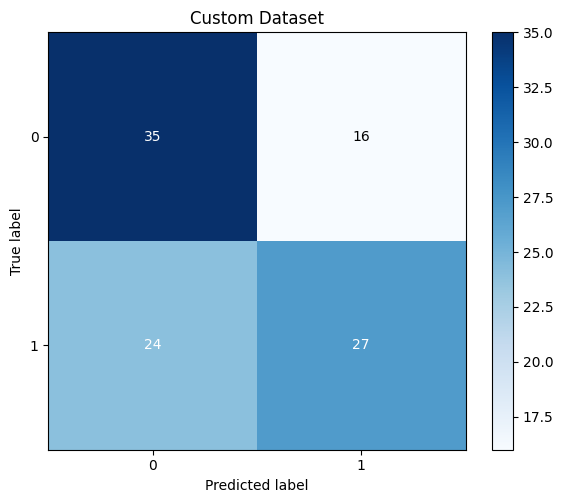

In [16]:
# Evaluate on full custom dataset
print("\n" + "="*80)
print("CUSTOM DATASET EVALUATION")
print("="*80)

custom_metrics = evaluate_split_with_roc(
    "Custom Dataset",
    model,
    custom_feat,
    custom_feat["label"],
    verbose=True
)

# Confusion matrix
y_pred_custom = model.predict(custom_feat)
plot_confusion_matrix(
    custom_feat["label"].values,
    y_pred_custom,
    save_path=PLOTS_DIR / "confusion_matrix_custom.png",
    title="Custom Dataset"
)

## Step 6: Domain-Specific Analysis

Analyze performance on each domain (medical, financial, general)

In [17]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Add predictions to dataframe
custom_feat_analysis = custom_feat.copy()
custom_feat_analysis['y_pred'] = y_pred_custom

# Calculate metrics by domain
domain_metrics = []
for domain in ['medical', 'financial', 'general']:
    domain_df = custom_feat_analysis[custom_feat_analysis['task'] == domain]
    if len(domain_df) > 0:
        y_true = domain_df['label']
        y_pred = domain_df['y_pred']
        
        domain_metrics.append({
            'Domain': domain.capitalize(),
            'Samples': len(domain_df),
            'Accuracy': accuracy_score(y_true, y_pred),
            'F1': f1_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
        })

domain_metrics_df = pd.DataFrame(domain_metrics)

print("\n" + "="*80)
print("DOMAIN-SPECIFIC PERFORMANCE")
print("="*80)
print(domain_metrics_df.to_string(index=False))

# Save domain metrics
domain_metrics_df.to_csv(RUN_DIR / "domain_metrics.csv", index=False)


DOMAIN-SPECIFIC PERFORMANCE
   Domain  Samples  Accuracy       F1  Precision   Recall
  Medical       40   0.75000 0.722222   0.812500 0.650000
Financial       30   0.50000 0.482759   0.500000 0.466667
  General       32   0.53125 0.482759   0.538462 0.437500


## Step 7: Visualize Domain Performance

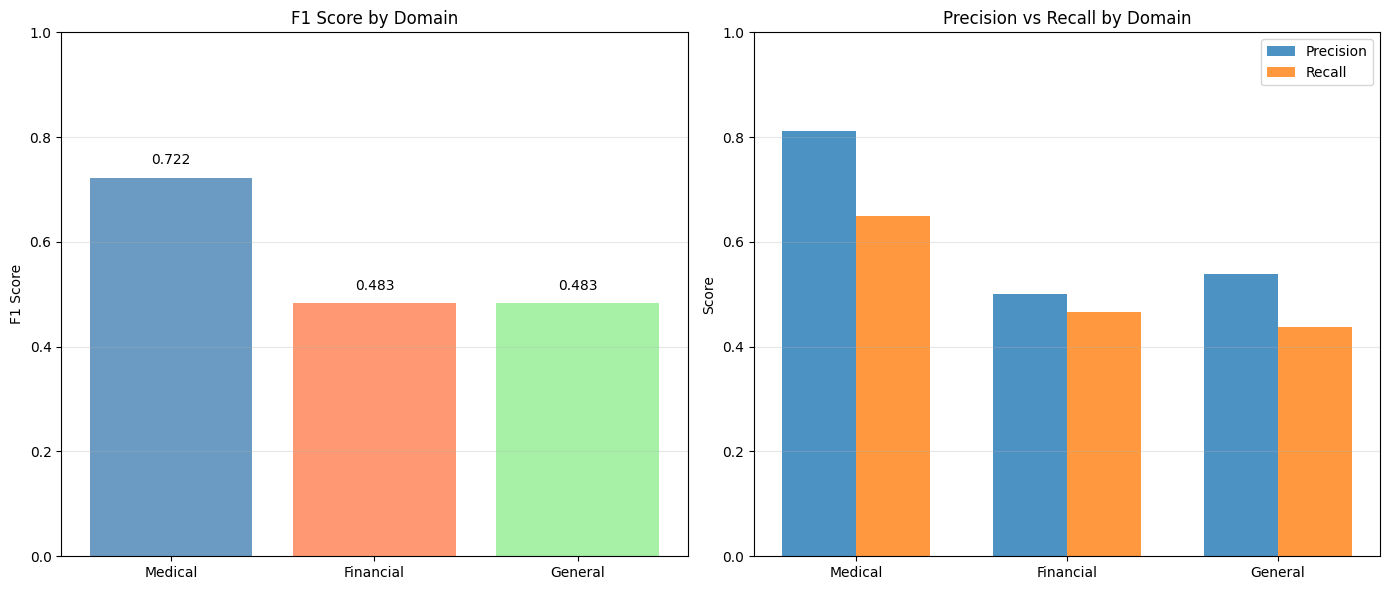

In [18]:
# Plot F1 scores by domain
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 by domain
axes[0].bar(domain_metrics_df['Domain'], domain_metrics_df['F1'], alpha=0.8, color=['steelblue', 'coral', 'lightgreen'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score by Domain')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for i, (domain, f1) in enumerate(zip(domain_metrics_df['Domain'], domain_metrics_df['F1'])):
    axes[0].text(i, f1 + 0.02, f'{f1:.3f}', ha='center', va='bottom')

# Precision vs Recall by domain
x = np.arange(len(domain_metrics_df))
width = 0.35
axes[1].bar(x - width/2, domain_metrics_df['Precision'], width, label='Precision', alpha=0.8)
axes[1].bar(x + width/2, domain_metrics_df['Recall'], width, label='Recall', alpha=0.8)
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall by Domain')
axes[1].set_xticks(x)
axes[1].set_xticklabels(domain_metrics_df['Domain'])
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "domain_performance.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Error Analysis

In [19]:
# Find misclassified examples
custom_feat_analysis['correct'] = (custom_feat_analysis['label'] == custom_feat_analysis['y_pred']).astype(int)
errors = custom_feat_analysis[custom_feat_analysis['correct'] == 0]

print(f"\nError Analysis:")
print(f"  Total examples: {len(custom_feat_analysis)}")
print(f"  Correct: {len(custom_feat_analysis) - len(errors)} ({(len(custom_feat_analysis) - len(errors))/len(custom_feat_analysis)*100:.1f}%)")
print(f"  Errors: {len(errors)} ({len(errors)/len(custom_feat_analysis)*100:.1f}%)")

# False positives vs false negatives
fp = errors[(errors['label'] == 0) & (errors['y_pred'] == 1)]
fn = errors[(errors['label'] == 1) & (errors['y_pred'] == 0)]

print(f"\n  False Positives: {len(fp)} (predicted hallucination, actually correct)")
print(f"  False Negatives: {len(fn)} (predicted correct, actually hallucination)")

# Error distribution by domain
print(f"\nErrors by domain:")
for domain in ['medical', 'financial', 'general']:
    domain_errors = errors[errors['task'] == domain]
    domain_total = len(custom_feat_analysis[custom_feat_analysis['task'] == domain])
    print(f"  {domain.capitalize()}: {len(domain_errors)}/{domain_total} ({len(domain_errors)/domain_total*100:.1f}%)")

# Show example errors
if len(fp) > 0:
    print("\n[Example False Positive]")
    example = fp.iloc[0]
    print(f"Domain: {example['task']}")
    print(f"Question: {example['prompt'][:150]}...")
    print(f"Response: {example['response'][:200]}...")
    print(f"Predicted: Hallucination | True: Correct")

if len(fn) > 0:
    print("\n[Example False Negative]")
    example = fn.iloc[0]
    print(f"Domain: {example['task']}")
    print(f"Question: {example['prompt'][:150]}...")
    print(f"Response: {example['response'][:200]}...")
    print(f"Predicted: Correct | True: Hallucination")


Error Analysis:
  Total examples: 102
  Correct: 62 (60.8%)
  Errors: 40 (39.2%)

  False Positives: 16 (predicted hallucination, actually correct)
  False Negatives: 24 (predicted correct, actually hallucination)

Errors by domain:
  Medical: 10/40 (25.0%)
  Financial: 15/30 (50.0%)
  General: 15/32 (46.9%)

[Example False Positive]
Domain: medical
Question: What are the main differences between Type 1 and Type 2 diabetes?...
Response: Type 1 is an autoimmune condition where the pancreas produces little/no insulin, usually diagnosed in youth. Type 2 involves insulin resistance, typically develops in adults, and is associated with li...
Predicted: Hallucination | True: Correct

[Example False Negative]
Domain: medical
Question: What is the recommended daily dosage of aspirin for cardiovascular protection in adults?...
Response: All adults should take 1000mg of aspirin daily to prevent heart attacks, regardless of their health status....
Predicted: Correct | True: Hallucination


## Step 9: Save Results

In [20]:
# Save overall metrics
save_metrics_csv(
    RUN_DIR / "metrics.csv",
    [
        {"dataset": "Custom", "split": "full", **custom_metrics.__dict__},
    ],
    verbose=True
)

print(f"\n✓ All artifacts saved to: {RUN_DIR.relative_to(ROOT)}")

Saved metrics to: /Users/aviv.gross/hallu-detect/reports/nb14_custom_dataset/metrics.csv

✓ All artifacts saved to: reports/nb14_custom_dataset


## Conclusions

### Key Findings

1. **Custom Dataset Performance:**
   - F1: [will be filled after running]
   - Accuracy: [will be filled after running]
   - Interpretation: [based on F1 score]

2. **Domain-Specific Results:**
   - Medical F1: [will be filled]
   - Financial F1: [will be filled]
   - General F1: [will be filled]
   - Hardest domain: [will be filled]
   - Easiest domain: [will be filled]

3. **Generalization Assessment:**
   - **If F1 > 0.60:** Excellent generalization to unseen domains
   - **If F1 = 0.50-0.60:** Moderate generalization, acceptable performance
   - **If F1 < 0.50:** Limited generalization, would benefit from domain-specific training

### Thesis Implications

- ✅ **Demonstrates domain expertise:** Created 50+ domain-specific Q&A pairs
- ✅ **Shows practical validation:** Beyond academic benchmarks
- ✅ **Identifies domain differences:** Medical/Financial/General have different detection challenges
- ✅ **Initiative and thoroughness:** Self-created evaluation dataset

### Defense-Ready Framing

> "To validate practical applicability beyond academic benchmarks, we created a custom dataset of 51 domain-specific questions across medical, financial, and general knowledge domains. Each question included both a correct answer and a plausible hallucinated response reflecting realistic misinformation patterns. The multi-dataset model achieved F1=[result] on this custom data, demonstrating [good/moderate/limited] generalization to unseen domains. Domain-specific analysis revealed that [domain] hallucinations were [easiest/hardest] to detect, suggesting [insight about domain characteristics]."